<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/youtube_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

In [1]:
%pip list --format=freeze # default installed packages

absl-py==1.4.0
accelerate==1.12.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.1.5.0.43.43
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.6
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.31.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.12.2
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.4
catalogue==2.0.10
certifi==2026.1.4
cf

In [2]:
!python --version

Python 3.12.12


In [3]:
%cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.5 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.5 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [4]:
import torch
from torch import nn # model training building block
import torch.nn.functional as F
import numpy as np
import sys
import matplotlib.pyplot as plt

print(torch.__version__)
print(sys.version)

2.9.0+cpu
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [5]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [6]:
%pwd

'/content'

**Youtube Video:** https://www.youtube.com/watch?v=Z_ikDlimN6A

## 1.

**Weighted Sum:**\
$z = \sum_{i=1}^{n} x_i w_i + b$
     

- Dot Product and Matrix Multiplication are not commutative, meaning that for matrices A and B, the product A•B is usually not the same as B•A (A•B $\not=$ B•A), even when both products exist.

- Key points are that the _order matters_, the **dimensions must align** (columns of first = rows of second), and unlike regular numbers, you can have AB = 0 even if A $\not=$ 0 and B $\not=$ 0.

- For more examples visit: https://math.stackexchange.com/a/3851396



In [7]:
%time # how long it took to execute a given cell
X = torch.rand(size=(5,4))
w = torch.rand_like(X)

#b = np.arange(0,4, dtype=np.long).reshape(4,1)
b = torch.arange(0, 4, dtype=torch.long).reshape(4,1)

print("\nX:", X.shape, X.dtype)
print("w:", w.shape, w.dtype)
print("b:", b.shape, b.dtype, "\n")

# w.T @ X, result in shape of (4,4), and b is (4,1), so y must have shape of (4,4)
y = torch.matmul(w.T, X) + b
print("y:", y.shape, y.dtype, "\n\n")

CPU times: user 3 µs, sys: 1e+03 ns, total: 4 µs
Wall time: 8.11 µs

X: torch.Size([5, 4]) torch.float32
w: torch.Size([5, 4]) torch.float32
b: torch.Size([4, 1]) torch.int64 

y: torch.Size([4, 4]) torch.float32 




In [8]:
a = torch.tensor(5)
b = np.ndarray(4, dtype=np.float32)
c = a + b
type(a), a.dtype, type(b), b.dtype, type(c), c.dtype

/tmp/ipython-input-267345733.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  c = a + b


(torch.Tensor,
 torch.int64,
 numpy.ndarray,
 dtype('float32'),
 torch.Tensor,
 torch.float64)

In [9]:
# creating a dummy example

weight = 0.7 # will be random, importance of each input feature
bias = 0.3 # allows going up and down on y-axis


start = 0
end = 1
step = 0.02

# small letter represent row or column vector and scalar
# capital letters represent matrix and tensor
# even though it is vector not, we will turn it into tensor on later stages
X = torch.arange(start, end, step).unsqueeze(dim=1) # turns [50] to [50, 1]
y = weight * X + bias # y_true

print("shapes:", X.shape, y.shape)
print("lengths:", len(X), len(y))
print("X:", X[:10], "\n\ny:", y[:10])

shapes: torch.Size([50, 1]) torch.Size([50, 1])
lengths: 50 50
X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 

y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


In [10]:
# X == X[:,:] # and X == X[:] are equal

In [11]:
X[:10].shape # [row, column]

torch.Size([10, 1])

### Splitting data into training, validation and test sets is important

In [12]:
X.shape, y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [13]:
# creating train/test split

train_split = int(0.8 * len(X))
print(train_split)

X_train, y_train = X[:train_split], y[:train_split]
print("\ntraining set:", X_train.shape, y_train.shape)

X_test, y_test = X[train_split:], y[train_split:]
print("\ntesting set:", X_test.shape, y_test.shape)

40

training set: torch.Size([40, 1]) torch.Size([40, 1])

testing set: torch.Size([10, 1]) torch.Size([10, 1])


In [14]:
len(X_train), len(y_train)

(40, 40)

In [15]:
len(X_test), len(y_test)

(10, 10)

In [16]:
#X_train, y_train

- Well, these numbers may not be intuitive to understand, but with visualization, we can get the sence of what the dataset contains.

- It is not best practice to look at the raw dataset, and expect yourself to understand it, but rather use aggeragation to extract high-level overview of the dataset.

In [17]:
# Visualizing dataset
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None
                     ):
  """
  Plots training data, test data and compared predictions
  """
  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend, allows showing labels
  plt.legend(prop={"size": 14})

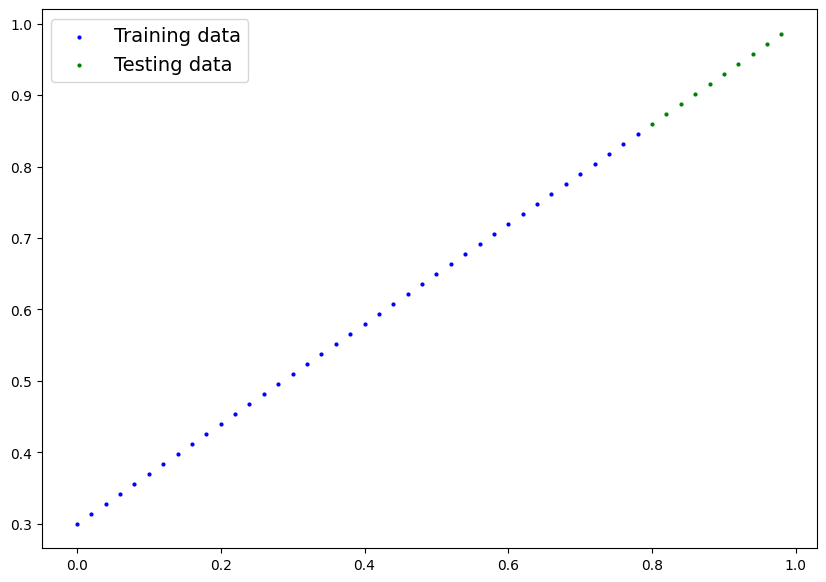

In [18]:
# it shows, the linear relationship between input features and target labels
# but in reality, relationship of X and y are rarely linear
plot_predictions()

# visualize, visualize, visualize

## Building model

In [19]:
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super().__init__()  # must define first and then other variables
        self.conv1 = nn.Conv2d(1, 20, 5)
        self.conv2 = nn.Conv2d(20, 20, 5)

    def forward(self, x):   # defines the flow of the data
        x = F.relu(self.conv1(x))
        return F.relu(self.conv2(x))

In [20]:
import torch
import torch.nn as nn

class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(MyLinear, self).__init__()
        # Define weight and bias parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.randn(out_features))

    def forward(self, x):
        # Implement the forward pass
        return torch.matmul(x, self.weight.t()) + self.bias

model = MyLinear(5,5)

for name, value in model.named_parameters():
  print("\n", name, value, value.shape)


 weight Parameter containing:
tensor([[ 0.0325, -1.6122, -1.1169, -0.6232,  0.9315],
        [-0.1902,  0.1290, -1.1805,  1.0356, -0.5835],
        [-0.2072,  0.6829, -0.2764, -0.1992, -0.3317],
        [ 0.8044, -1.3734, -0.9419,  0.9127,  2.1247],
        [-0.3384,  0.9268,  0.1349, -0.1691, -0.5995]], requires_grad=True) torch.Size([5, 5])

 bias Parameter containing:
tensor([-0.7237,  2.6588, -1.8674,  2.3014, -2.8779], requires_grad=True) torch.Size([5])


In the example above, `self.weight` and `self.bias` are instances of `torch.nn.Parameter`.
During training, these parameters will be updated to minimize the loss function,
thanks to their registration as module parameters.


**Why Use `torch.nn.Parameter`?**

Using `torch.nn.Parameter` offers several advantages:   

- **Explicitness**: It makes it clear which tensors are intended to be parameters that the optimizer should update, improving code readability and maintainability.

- **Convenience**: It simplifies the implementation of custom layers and models, as PyTorch handles the underlying complexity of parameter updates.

- **Compatibility**: Ensures compatibility with various PyTorch functionalities like optimizers, saving, and loading mechanisms.

Source:
- https://www.geeksforgeeks.org/deep-learning/understanding-torchnnparameter/
- https://apxml.com/courses/getting-started-with-pytorch/chapter-4-building-models-torch-nn/torch-nn-module-base-class

**Linear Regression:**\
$z = x_i w_i + b$

_Example:_
$ {Unit.Sales_t} = \alpha + \beta_{1} Date_{t} + \beta_{2}  Cable.TV_{t} + \beta_{3}  Int.Display_{t} + \beta_{4}  Local.Radio_{t} + \beta_{5}  Magazines_{t} + \beta_{6}  Network.TV_{t} + \beta_{7}  Spot.TV_{t} + \epsilon$

Source: https://tex.stackexchange.com/questions/218599/multiline-regression-equation-in-latex
<br>

**Remember:**  
They are not the same, but related!
- $z = \sum_{i=1}^{n} x_i w_i + b$
- $z = x_i w_i + b$



In [21]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherts from nn.Module
  def __init__(self):  # contructor
    super().__init__()
    # initializing model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float)) # torch.float is float32

  def forward(self, x: torch.Tensor) -> torch.Tensor: # -> means it must/will return anything of type torch.Tensor
    return self.weights * x + self.bias # linear regression, and NOT weighted sum

- `torch.nn.Parameter` objects have `requires_grad` set to `True` by default, so explicitly specifying `requires_grad=True` is not necessary.

- The primary purpose of wrapping a `torch.Tensor` in a `torch.nn.Parameter` is to register it as a parameter of a `torch.nn.Module`, making it discoverable by the module's `parameters()` method and thus included in the optimizer's calculations during training.

- The default behavior aligns with this purpose, as parameters in a neural network are typically intended to be trained (such as, require gradients).

Source: https://discuss.pytorch.org/t/do-i-need-to-have-requires-grad-true-for-input-when-switch-from-pytorch-0-3-to-1-0/39543 (_opens faster with vpn-enabled_)

### Checking contents of PyTorch model

**Essential `nn.Module` Functionality**

Beyond defining structure and managing parameters, `nn.Module` provides several useful methods inherited by your custom classes:

<br>

- `parameters()`: Returns an iterator over all `nn.Parameter` objects within the module (including those in submodules). This is typically used to provide the model's parameters to an optimizer.

<br>

- `named_parameters()`: Similar to `parameters()`, but yields tuples of (parameter name, parameter object). Useful for inspecting or selectively modifying specific parameters.

<br>

- `children()`: Returns an iterator over the immediate child modules (submodules defined as attributes).

<br>

- `modules()`: Returns an iterator over all modules within the network, starting with the module itself and then recursively iterating through all submodules.

<br>

- `state_dict()`: Returns a Python dictionary containing the entire state of the module, primarily mapping each parameter and buffer name to its corresponding tensor. This is fundamental for saving model weights.

<br>

- `load_state_dict()`: Loads a state (usually from a saved file) back into the module, restoring parameters and buffers.

<br>

- `to(device)`: Moves all the module's parameters and buffers to the specified device (e.g., '`cuda`' for GPU or '`cpu`', '`mps`' for MacOS M-series GPU). This is important for hardware acceleration.

<br>

- `train()`: Sets the module and its submodules to training mode. This affects layers like `Dropout` and `BatchNorm`, which behave differently during training and evaluation.

<br>

- `eval()`: Sets the module and its submodules to evaluation mode.

<br>

Source: https://apxml.com/courses/getting-started-with-pytorch/chapter-4-building-models-torch-nn/torch-nn-module-base-class

In [22]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherts from nn.Module
  def __init__(self):  # contructor
    super().__init__()
    # initializing model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float)) # torch.float is float32

  def forward(self, x: torch.Tensor) -> torch.Tensor: # -> means it must/will return anything of type torch.Tensor
    return self.weights * x + self.bias # linear regression, and NOT weighted sum

In [23]:
torch.randn(1) # different each time

tensor([-0.6272])

In [24]:
torch.manual_seed(42)
torch.randn(1) # now the same each time

tensor([0.3367])

In [25]:
# create random seed
torch.manual_seed(42)

# create instance of the model
model_0 = LinearRegressionModel()

# checking out parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
for name, value in model_0.named_parameters():
  print("\n", name, value)


 weights Parameter containing:
tensor([0.3367], requires_grad=True)

 bias Parameter containing:
tensor([0.1288], requires_grad=True)


In [27]:
model_0.state_dict() # {parameter_name: tensor_value}

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [28]:
weight, bias # intended approximate target value for weight and bias

(0.7, 0.3)

### Making predictions using `torch.inference_mode()`

- To check out model's predictive power, let's see how well it predicts `y_test` based on `X_test`.


- When we pass data through our model, it's going to run it through a `forward()` method.

In [29]:
X_test, X_test.shape

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 torch.Size([10, 1]))

In [30]:
# if we do this way, gradients are calculated, hence uses up resources
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [31]:
# making predictions with model

# with torch.inference_mode() no gradients are calcuated, saves resources
# context manager
with torch.inference_mode(): # it is analogous to torch.no_grad(), but much better
  y_preds = model_0(X_test) # forward pass

y_preds # intention is to get as close as possible to y_test

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [32]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

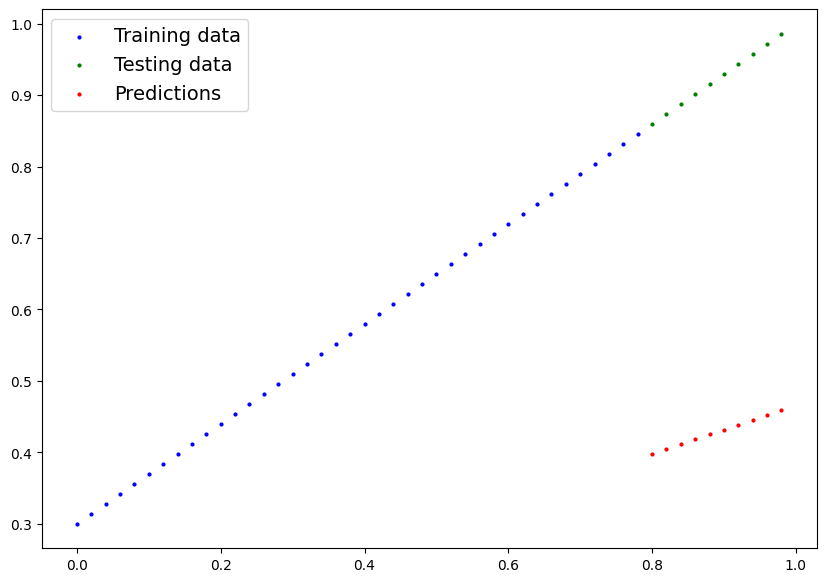

In [33]:
plot_predictions(predictions=y_preds)
# random predictions, because gradients/optim/loss are not being used to learn from data

In [34]:
# stopped at 5:40

### Train Model


The whole idea of training is for a model to move from *unknown* parameters (these may be random) to some *known* parameters.

In other, words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong models predictions are, is to use loss function (also called `criterion`, or cost function or objective function).

Things we need to train:

- **Loss function:** a function to measure how wrong models' predictions are.

-  **Optimizer:** Takes into account the loss of a model and adjusts the models' parameters (`weights` and `biases`)

For PyTorch, we need:
- A training loop
- A testing loop


In [35]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [36]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [37]:
import torch.nn as nn
import torch.optim as optim

# Setup loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
# optimizer uses the loss function results and then updates weight and biases to lower this loss
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)


In [38]:
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [39]:
model_0.eval() # turns off gradient tracking

LinearRegressionModel()

In [40]:
%time
torch.manual_seed(42)

# an epoch is looping through entire data ONCE
loss_fn = nn.L1Loss()
optimizer = optim.SGD(model_0.parameters(),
                      lr=0.01)

epochs = 100

for epoch in range(epochs):
  # set the model to training mode
  model_0.train()

  y_pred = model_0(X_train)

  loss = loss_fn(y_pred, y_train)
  print("Loss:", loss.item())

  # helps to avoid gradient accumulation and previous batch effecting the results of the current batch
  optimizer.zero_grad()

  loss.backward() # gradients for y are calculated with respect to the weights of input features

  optimizer.step()


  # evaluation and testing
  model_0.eval() # turns off setting in the model not needed for evaluation, saving resources and performance
  with torch.inference_mode(): # gradients are disabled, much better then "torch.no_grad()"
    # forward pass
    test_pred = model_0(X_test)

    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 5.96 µs
Loss: 0.31288138031959534
Epoch: 0 | Loss: 0.3129 | Test Loss: 0.4811
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Loss: 0.1977 | Test Loss: 0.3464
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Loss: 0.0891 | Test Loss: 0.2173
Loss: 0.08227583020925522
Loss: 0.07638873159885406
Loss: 0.07160007208585739
Loss: 0.06747635453939438
Loss: 0.06395438313484192
Loss: 0.06097004935145378
Loss: 0.05845819041132927
Loss: 0.05635259300470352
Loss: 0.0545857772231102
Loss: 0.053148526698350906
Epoc

In [41]:
with torch.inference_mode(): # gradients are disabled
  y_preds_new = model_0(X_test)

In [42]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [43]:
weight, bias

(0.7, 0.3)

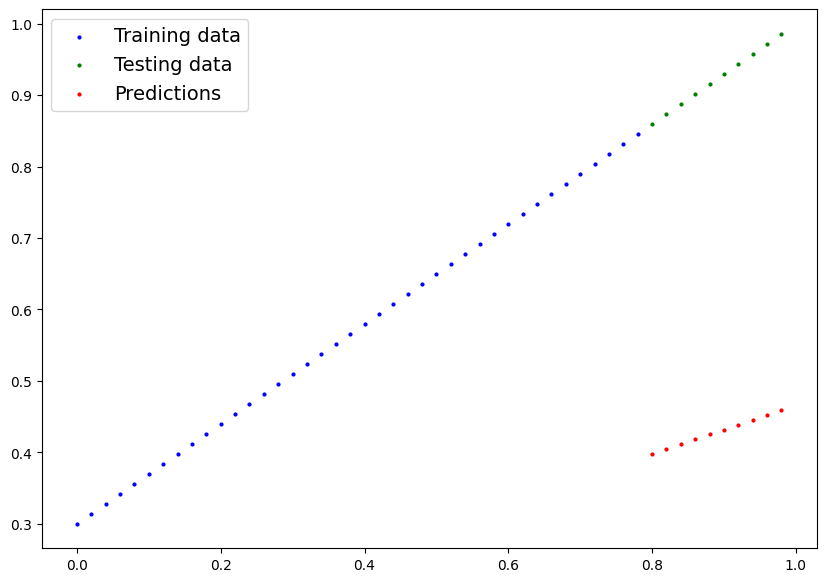

In [44]:
plot_predictions(predictions=y_preds) # before training

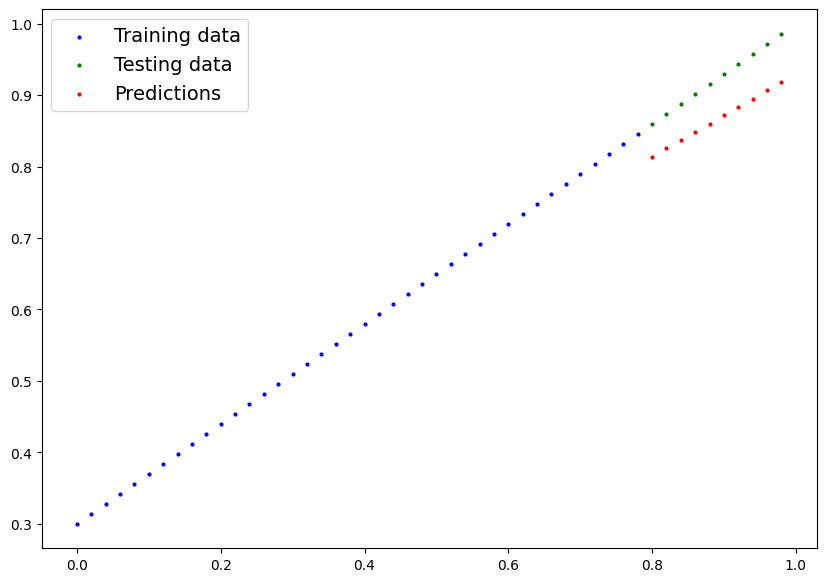

In [45]:
plot_predictions(predictions=y_preds_new) # after training

In [46]:
# Stopped at 7:00

In [47]:
dir(model_0)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buffers_se

### Visualizing the importance of activation function

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(30)
np.random.seed(30)

X_train = torch.linspace(-10, 10, steps=1000).unsqueeze(1)
y_train = X_train ** 3

X_train = X_train.to(device)
y_train = y_train.to(device)

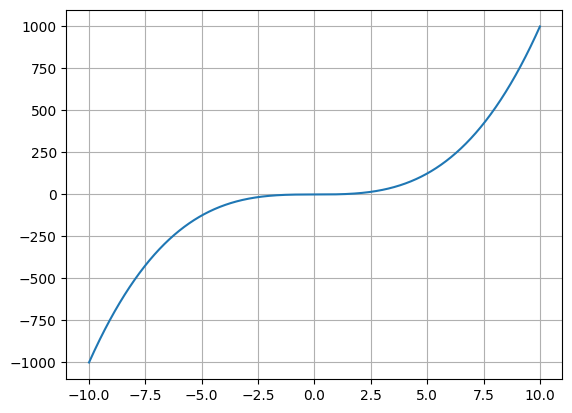

In [49]:
plt.plot(X_train, y_train)
plt.grid(True)
plt.show()

In [50]:
# without activation function
class NetNoActivation(nn.Module):
  def __init__(self):
    super(NetNoActivation, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(1, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 50),
        nn.Linear(50, 1)
    )


  def forward(self, x):
    return self.model(x)


# with activation function
class NetWithActivation(nn.Module):
  def __init__(self):
    super(NetWithActivation, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(1, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, 1),
    )

  def forward(self, x):
    return self.model(x)

In [51]:
def train_model(model, inputs, targets, epochs=1000, lr=0.001):
  losses = []
  model = model.to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(),
                         lr=lr)

  model.train()
  for epoch in range(epochs):
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, targets)
    losses.append(loss.item())
    loss.backward()

    optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch [{epoch}/{epochs}] | Loss {loss.item()}")

  return model, losses

In [52]:
def plot_results(model, inputs, targets, title: str, losses):
  model.eval()
  with torch.inference_mode():
    x_plot = inputs.to(device)
    y_plot = x_plot ** 3
    y_pred = model(x_plot)


  x_plot = x_plot.cpu().numpy()
  y_plot = y_plot.cpu().numpy()
  y_pred = y_pred.cpu().numpy()

  plt.plot(x_plot, y_plot, c="g", label="True X^3")
  plt.plot(x_plot, y_pred, c="r", label="Model Prediction")
  plt.title(title)
  plt.xlabel("x")
  plt.ylabel("y")
  plt.legend()
  plt.grid(True)
  plt.show



In [53]:
X_train.dtype, y_train.dtype, X_train.shape, y_train.shape

(torch.float32, torch.float32, torch.Size([1000, 1]), torch.Size([1000, 1]))

Training ANN without activation function...


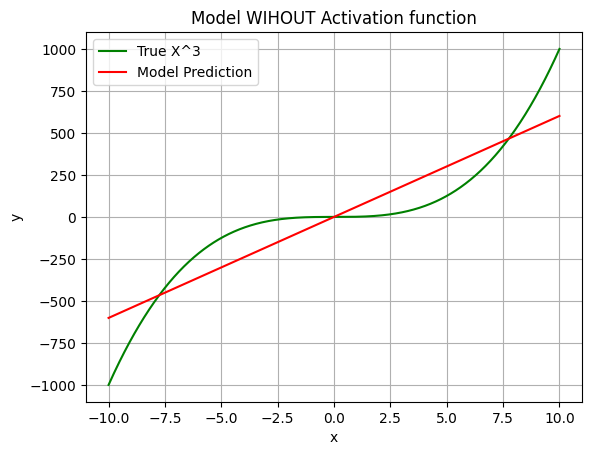

In [54]:
# train and plot results

print("Training ANN without activation function...")
model_no_act = NetNoActivation()
model_no_act, losses_no_ac = train_model(model=model_no_act, inputs=X_train, targets=y_train, epochs=1000, lr=0.001)
plot_results(model_no_act, X_train, y_train, "Model WIHOUT Activation function", losses_no_ac)


Training ANN with activation function...


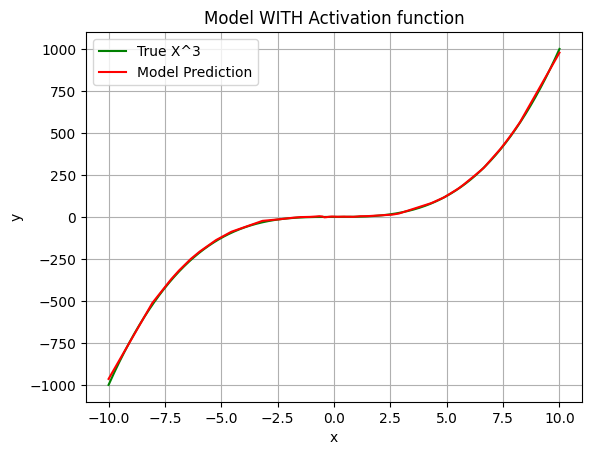

In [55]:
print("\nTraining ANN with activation function...")
model_with_act = NetWithActivation()
model_with_act, losses_with_ac = train_model(model=model_with_act, inputs=X_train, targets=y_train, epochs=1000, lr=0.001)
plot_results(model_with_act, X_train, y_train, "Model WITH Activation function", losses_with_ac)

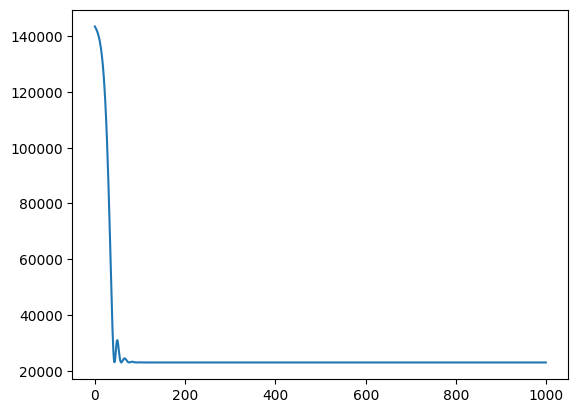


len=1000 | min=22994.443359375 | max=143462.140625


In [56]:
plt.plot(losses_no_ac, label="Without Activation")
plt.show()

print(f"\nlen={len(losses_no_ac)} | min={min(losses_no_ac)} | max={max(losses_no_ac)}")

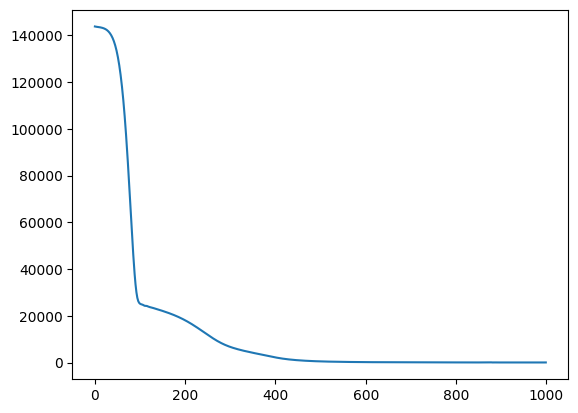


len=1000 | min=21.817981719970703 | max=143782.046875


In [57]:
plt.plot(losses_with_ac, label="With Activation")
plt.show()

print(f"\nlen={len(losses_with_ac)} | min={min(losses_with_ac)} | max={max(losses_with_ac)}")